<a href="https://colab.research.google.com/github/thuynguyenhuit/hocsau/blob/main/M%C3%B4_h%C3%ACnh_MLP_Dry_Bean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
pd_train = pd.read_csv("https://raw.githubusercontent.com/thuynguyenhuit/hocsau/refs/heads/main/Dry_Bean_Dataset.csv")

In [22]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim

In [23]:
pd_train.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [24]:
# =========================================
# 3. KIỂM TRA DỮ LIỆU
# =========================================
print(pd_train.info())

print(pd_train["Class"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [25]:
# =========================================
# Mã hóa nhãn (Label Encoding) cho biến mục tiêu
# =========================================

encoder = LabelEncoder()

pd_train["Class"] = encoder.fit_transform(pd_train["Class"])

print(pd_train.head())

    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272751  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0.913358      0.007332  

In [26]:
# =========================================
# 5. TÁCH X VÀ y
# =========================================

X = pd_train.drop("Class", axis=1)

y = pd_train["Class"]

In [27]:
# =========================================
# 6. CHIA TRAIN / VAL / TEST
# =========================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [28]:
# =========================================
# 7. SCALE FEATURES
# =========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

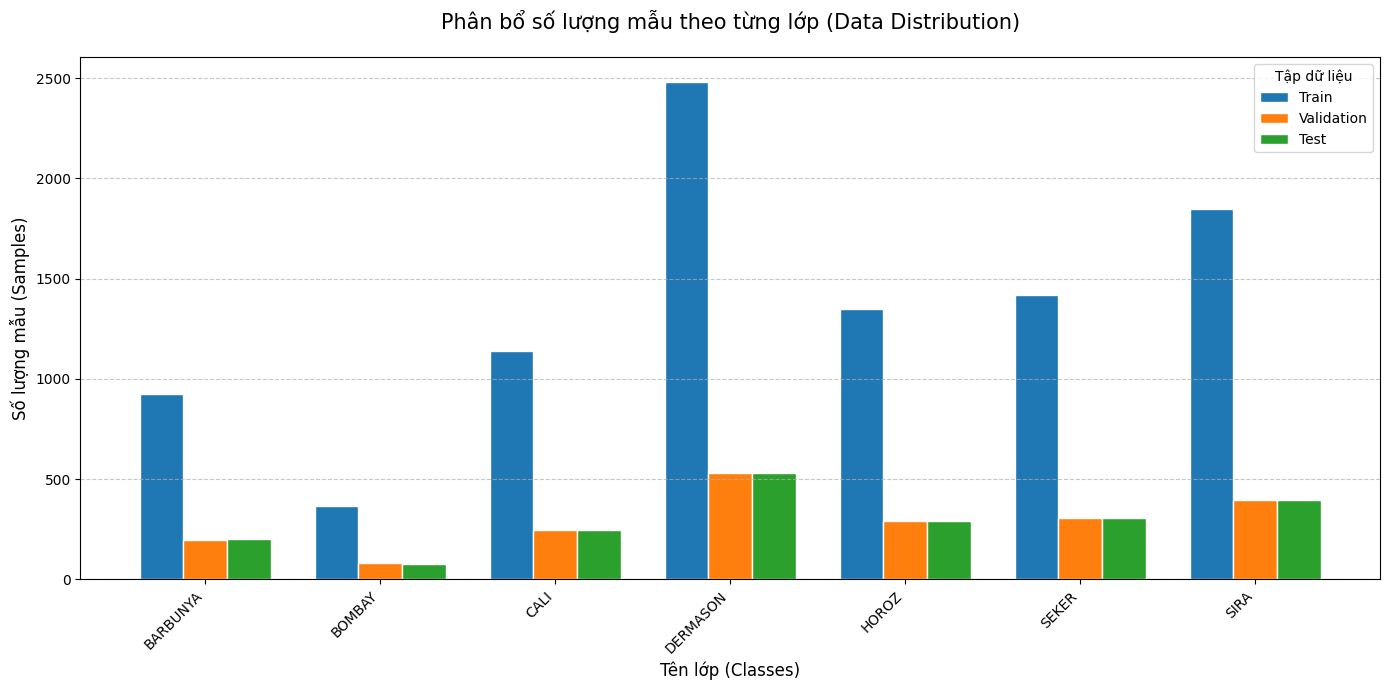

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# 1. ĐẾM SỐ LƯỢNG MẪU (Trực tiếp từ Series)
# =========================================
# Giả định y_train, y_val, y_test là các Pandas Series
# Nếu chúng là Tensor, hãy dùng .to_numpy() trước khi đếm

train_counts = y_train.value_counts().sort_index()
val_counts = y_val.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

# =========================================
# 2. CLASS NAMES
# =========================================
# Lấy tên các lớp từ LabelEncoder bạn đã dùng trước đó
class_names = encoder.classes_

# =========================================
# 3. VẼ BIỂU ĐỒ CỘT (GROUPED BAR CHART)
# =========================================
x = range(len(class_names))
width = 0.25  # Độ rộng của mỗi cột

plt.figure(figsize=(14, 7))

# Vẽ từng nhóm cột cho Train, Validation, Test
plt.bar(
    [i - width for i in x],
    train_counts,
    width=width,
    label='Train',
    color='#1f77b4',
    edgecolor='white'
)

plt.bar(
    x,
    val_counts,
    width=width,
    label='Validation',
    color='#ff7f0e',
    edgecolor='white'
)

plt.bar(
    [i + width for i in x],
    test_counts,
    width=width,
    label='Test',
    color='#2ca02c',
    edgecolor='white'
)

# =========================================
# 4. TRÌNH BÀY (LABELS & STYLE)
# =========================================
plt.title("Phân bổ số lượng mẫu theo từng lớp (Data Distribution)", fontsize=15, pad=20)
plt.xlabel("Tên lớp (Classes)", fontsize=12)
plt.ylabel("Số lượng mẫu (Samples)", fontsize=12)

# Thiết lập nhãn trục X
plt.xticks(x, class_names, rotation=45, ha='right')

# Thêm chú thích
plt.legend(title="Tập dữ liệu")

# Thêm lưới ngang để dễ quan sát số lượng
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tự động căn chỉnh để không bị mất nhãn phía dưới
plt.tight_layout()

plt.show()

In [31]:
# =========================================
# 8. CHUYỂN SANG TENSOR
# =========================================

X_train = torch.tensor(X_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)


y_train = torch.tensor(y_train.values, dtype=torch.long)

y_val = torch.tensor(y_val.values, dtype=torch.long)

y_test = torch.tensor(y_test.values, dtype=torch.long)

In [32]:
# =========================================
# 9. INPUT SIZE
# =========================================

input_size = X_train.shape[1]

print(input_size)

16


MÔ HÌNH KHÔNG DROPOUT

In [56]:
# =========================================
# 10. MODEL KHÔNG DROPOUT
# =========================================

class MLP_NoDropout(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 7)
        )

    def forward(self, x):
        return self.network(x)

MÔ HÌNH CÓ DROPOUT

In [57]:
# =========================================
# 11. MODEL CÓ DROPOUT
# =========================================

class MLP_Dropout(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(64, 7)
        )

    def forward(self, x):
        return self.network(x)

TRAIN MODEL

In [60]:
# =========================================
# 12. HÀM TRAIN
# =========================================

def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=300
):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        # =========================
        # TRAIN
        # =========================

        model.train()

        outputs = model(X_train)

        loss = criterion(outputs, y_train)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_losses.append(loss.item())

        _, predicted = torch.max(outputs, 1)

        train_acc = (
            predicted == y_train
        ).float().mean()

        train_accuracies.append(
            train_acc.item()
        )

        # =========================
        # VALIDATION
        # =========================

        model.eval()

        with torch.no_grad():

            val_outputs = model(X_val)

            val_loss = criterion(
                val_outputs,
                y_val
            )

            val_losses.append(
                val_loss.item()
            )

            _, val_predicted = torch.max(
                val_outputs,
                1
            )

            val_acc = (
                val_predicted == y_val
            ).float().mean()

            val_accuracies.append(
                val_acc.item()
            )

        if (epoch + 1) % 20 == 0:

            print(
                f"Epoch {epoch+1}/{epochs}"
                f" | Train Loss: {loss.item():.4f}"
                f" | Val Loss: {val_loss.item():.4f}"
                f" | Train Acc: {train_acc.item():.4f}"
                f" | Val Acc: {val_acc.item():.4f}"
            )

    return (
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies
    )

TRAIN MODEL KHÔNG DROPOUT

In [61]:
# =========================================
# 13. TRAIN NO DROPOUT
# =========================================

model_no_dropout = MLP_NoDropout(input_size)

(
    train_loss_no,
    val_loss_no,
    train_acc_no,
    val_acc_no

) = train_model(
    model_no_dropout,
    X_train,
    y_train,
    X_val,
    y_val
)

Epoch 20/300 | Train Loss: 1.0517 | Val Loss: 1.0016 | Train Acc: 0.6969 | Val Acc: 0.7101
Epoch 40/300 | Train Loss: 0.4035 | Val Loss: 0.3889 | Train Acc: 0.8773 | Val Acc: 0.8717
Epoch 60/300 | Train Loss: 0.2595 | Val Loss: 0.2572 | Train Acc: 0.9093 | Val Acc: 0.9045
Epoch 80/300 | Train Loss: 0.2118 | Val Loss: 0.2160 | Train Acc: 0.9243 | Val Acc: 0.9207
Epoch 100/300 | Train Loss: 0.1956 | Val Loss: 0.2060 | Train Acc: 0.9288 | Val Acc: 0.9246
Epoch 120/300 | Train Loss: 0.1875 | Val Loss: 0.2006 | Train Acc: 0.9317 | Val Acc: 0.9270
Epoch 140/300 | Train Loss: 0.1822 | Val Loss: 0.1985 | Train Acc: 0.9342 | Val Acc: 0.9295
Epoch 160/300 | Train Loss: 0.1782 | Val Loss: 0.1970 | Train Acc: 0.9353 | Val Acc: 0.9290
Epoch 180/300 | Train Loss: 0.1749 | Val Loss: 0.1958 | Train Acc: 0.9354 | Val Acc: 0.9285
Epoch 200/300 | Train Loss: 0.1719 | Val Loss: 0.1948 | Train Acc: 0.9373 | Val Acc: 0.9305
Epoch 220/300 | Train Loss: 0.1692 | Val Loss: 0.1945 | Train Acc: 0.9381 | Val Acc:

TRAIN MODEL CÓ DROPOUT

In [62]:
# =========================================
# 14. TRAIN DROPOUT
# =========================================

model_dropout = MLP_Dropout(input_size)

(
    train_loss_drop,
    val_loss_drop,
    train_acc_drop,
    val_acc_drop

) = train_model(
    model_dropout,
    X_train,
    y_train,
    X_val,
    y_val
)

Epoch 20/300 | Train Loss: 0.9298 | Val Loss: 0.8338 | Train Acc: 0.6951 | Val Acc: 0.7258
Epoch 40/300 | Train Loss: 0.4103 | Val Loss: 0.3282 | Train Acc: 0.8617 | Val Acc: 0.8903
Epoch 60/300 | Train Loss: 0.2883 | Val Loss: 0.2397 | Train Acc: 0.9005 | Val Acc: 0.9158
Epoch 80/300 | Train Loss: 0.2559 | Val Loss: 0.2147 | Train Acc: 0.9107 | Val Acc: 0.9216
Epoch 100/300 | Train Loss: 0.2305 | Val Loss: 0.2055 | Train Acc: 0.9208 | Val Acc: 0.9241
Epoch 120/300 | Train Loss: 0.2236 | Val Loss: 0.2020 | Train Acc: 0.9235 | Val Acc: 0.9246
Epoch 140/300 | Train Loss: 0.2134 | Val Loss: 0.2009 | Train Acc: 0.9233 | Val Acc: 0.9270
Epoch 160/300 | Train Loss: 0.2076 | Val Loss: 0.2000 | Train Acc: 0.9282 | Val Acc: 0.9265
Epoch 180/300 | Train Loss: 0.2040 | Val Loss: 0.1986 | Train Acc: 0.9278 | Val Acc: 0.9285
Epoch 200/300 | Train Loss: 0.2026 | Val Loss: 0.1982 | Train Acc: 0.9286 | Val Acc: 0.9280
Epoch 220/300 | Train Loss: 0.2007 | Val Loss: 0.1972 | Train Acc: 0.9280 | Val Acc:

VẼ LOSS CURVE

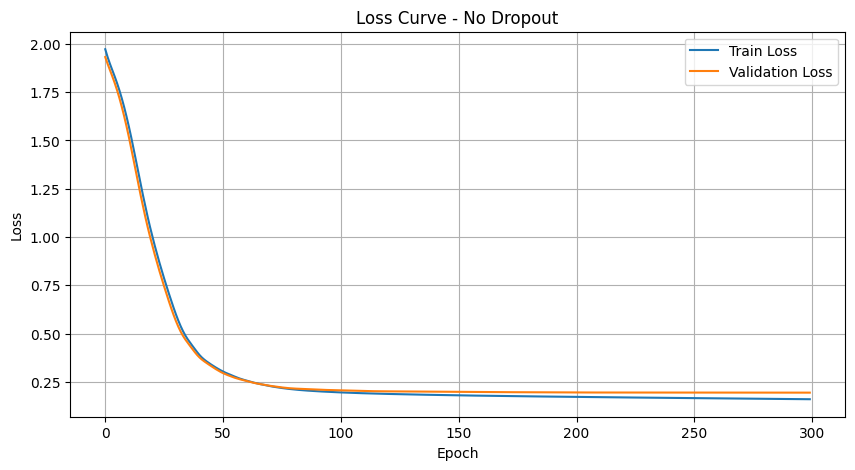

In [63]:
# =========================================
# LOSS CURVE - NO DROPOUT
# =========================================

plt.figure(figsize=(10,5))

plt.plot(
    train_loss_no,
    label="Train Loss"
)

plt.plot(
    val_loss_no,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Curve - No Dropout")

plt.legend()

plt.grid(True)

plt.show()

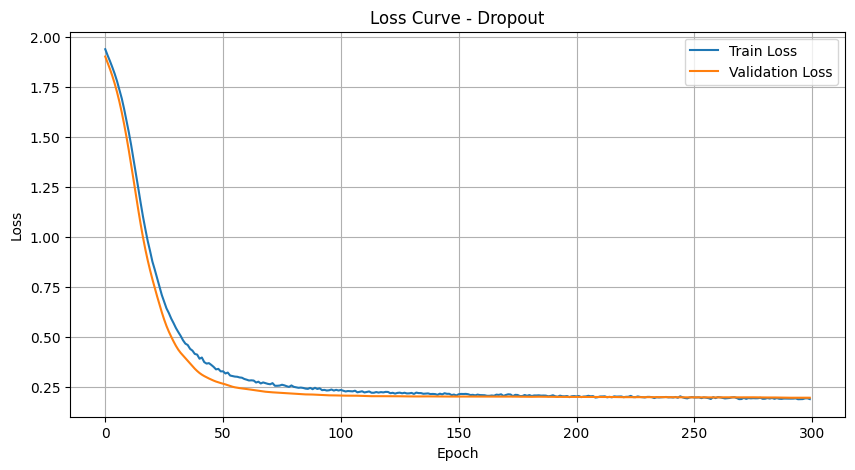

In [64]:
# =========================================
# LOSS CURVE - DROPOUT
# =========================================

plt.figure(figsize=(10,5))

plt.plot(
    train_loss_drop,
    label="Train Loss"
)

plt.plot(
    val_loss_drop,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Curve - Dropout")

plt.legend()

plt.grid(True)

plt.show()

VẼ ACCURACY CURVE

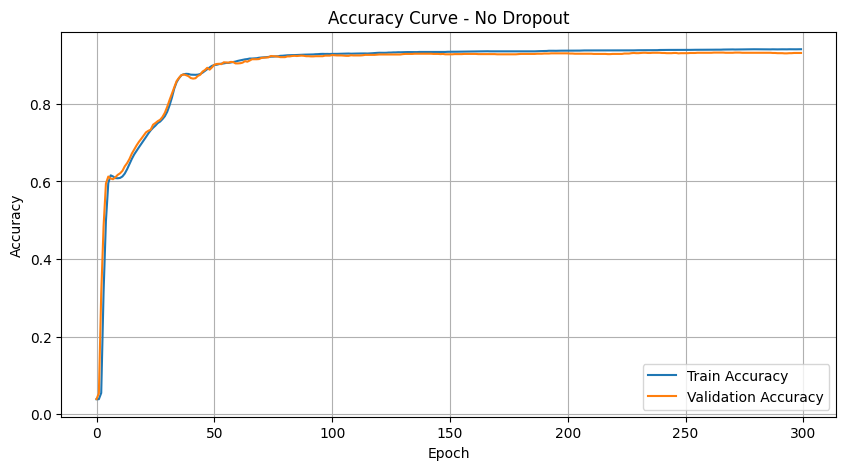

In [65]:
# =========================================
# ACCURACY CURVE - NO DROPOUT
# =========================================

plt.figure(figsize=(10,5))

plt.plot(
    train_acc_no,
    label="Train Accuracy"
)

plt.plot(
    val_acc_no,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy Curve - No Dropout")

plt.legend()

plt.grid(True)

plt.show()

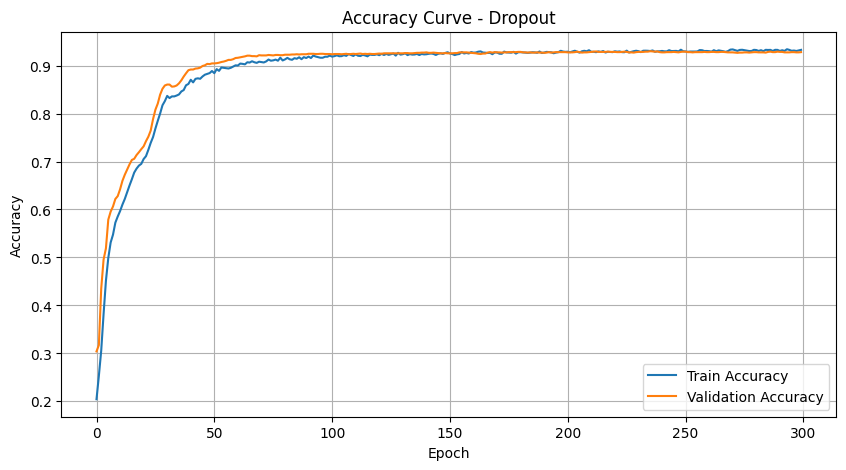

In [66]:
# =========================================
# ACCURACY CURVE - DROPOUT
# =========================================

plt.figure(figsize=(10,5))

plt.plot(
    train_acc_drop,
    label="Train Accuracy"
)

plt.plot(
    val_acc_drop,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy Curve - Dropout")

plt.legend()

plt.grid(True)

plt.show()

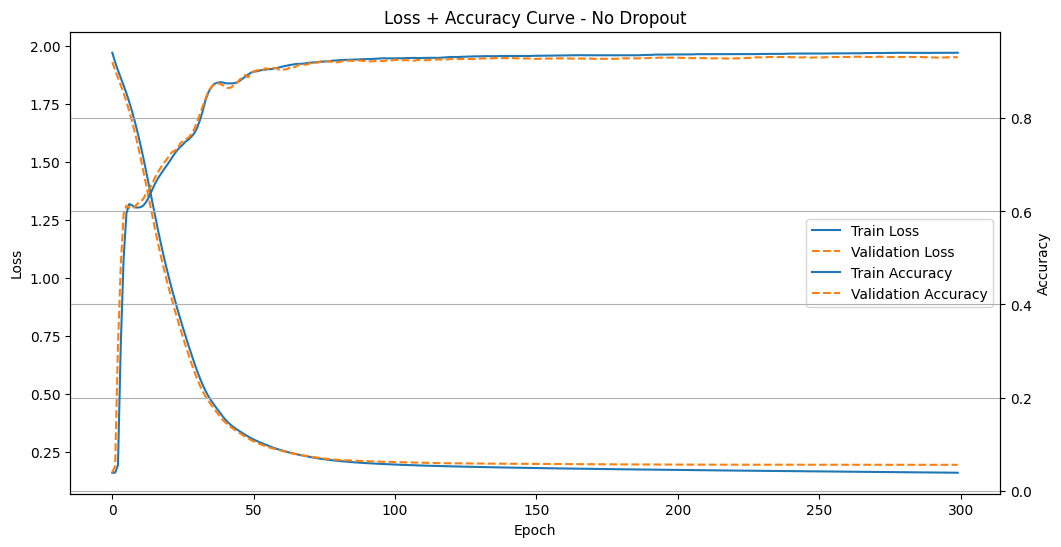

In [67]:
# =========================================
# LOSS + ACCURACY CURVE - NO DROPOUT
# =========================================

fig, ax1 = plt.subplots(figsize=(12,6))

# =========================
# LOSS
# =========================

ax1.plot(
    train_loss_no,
    label='Train Loss',
    linestyle='-'
)

ax1.plot(
    val_loss_no,
    label='Validation Loss',
    linestyle='--'
)

ax1.set_xlabel('Epoch')

ax1.set_ylabel('Loss')

# =========================
# ACCURACY
# =========================

ax2 = ax1.twinx()

ax2.plot(
    train_acc_no,
    label='Train Accuracy',
    linestyle='-'
)

ax2.plot(
    val_acc_no,
    label='Validation Accuracy',
    linestyle='--'
)

ax2.set_ylabel('Accuracy')

# =========================
# TITLE
# =========================

plt.title("Loss + Accuracy Curve - No Dropout")

# =========================
# LEGEND
# =========================

lines_1, labels_1 = ax1.get_legend_handles_labels()

lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='center right'
)

plt.grid(True)

plt.show()

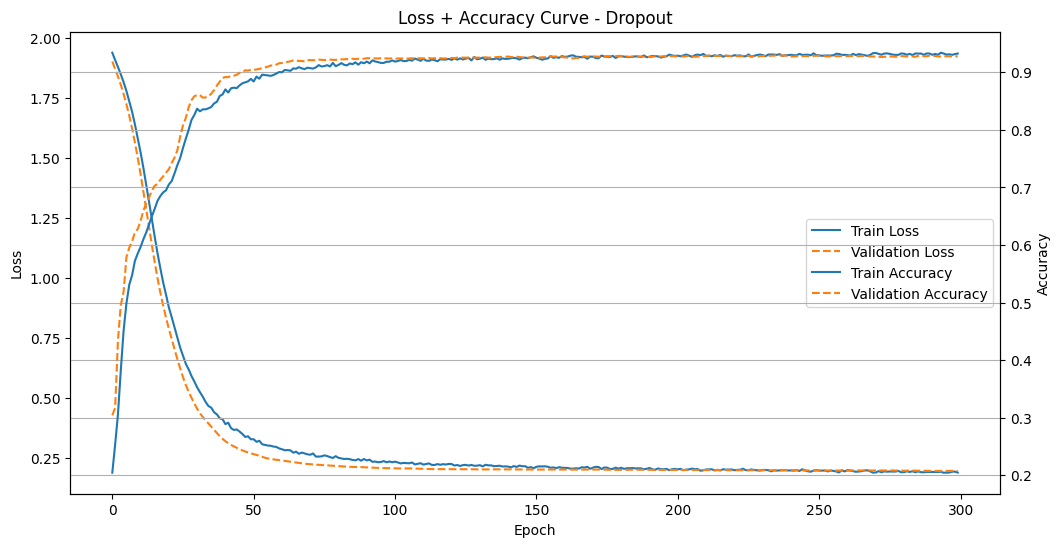

In [68]:
# =========================================
# LOSS + ACCURACY CURVE - DROPOUT
# =========================================

fig, ax1 = plt.subplots(figsize=(12,6))

# =========================
# LOSS
# =========================

ax1.plot(
    train_loss_drop,
    label='Train Loss',
    linestyle='-'
)

ax1.plot(
    val_loss_drop,
    label='Validation Loss',
    linestyle='--'
)

ax1.set_xlabel('Epoch')

ax1.set_ylabel('Loss')

# =========================
# ACCURACY
# =========================

ax2 = ax1.twinx()

ax2.plot(
    train_acc_drop,
    label='Train Accuracy',
    linestyle='-'
)

ax2.plot(
    val_acc_drop,
    label='Validation Accuracy',
    linestyle='--'
)

ax2.set_ylabel('Accuracy')

# =========================
# TITLE
# =========================

plt.title("Loss + Accuracy Curve - Dropout")

# =========================
# LEGEND
# =========================

lines_1, labels_1 = ax1.get_legend_handles_labels()

lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='center right'
)

plt.grid(True)

plt.show()

HÀM ĐÁNH GIÁ

In [69]:
# =========================================
# 17. EVALUATE MODEL + CONFUSION MATRIX
# =========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def evaluate_model(model, X_test, y_test):

    # =========================
    # EVALUATION MODE
    # =========================

    model.eval()

    with torch.no_grad():

        outputs = model(X_test)

        _, predictions = torch.max(outputs, 1)

    # =========================
    # NUMPY
    # =========================

    predictions = predictions.numpy()

    y_true = y_test.numpy()

    # =========================
    # ACCURACY
    # =========================

    accuracy = accuracy_score(
        y_true,
        predictions
    )

    print(f"\nAccuracy: {accuracy:.4f}")

    # =========================
    # CLASSIFICATION REPORT
    # =========================

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_true,
            predictions,
            target_names=encoder.classes_
        )
    )

    # =========================
    # CONFUSION MATRIX
    # =========================

    cm = confusion_matrix(
        y_true,
        predictions
    )

    plt.figure(figsize=(10,8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=encoder.classes_
    )

    disp.plot(
        cmap="Blues",
        values_format='d'
    )

    plt.title("Confusion Matrix")

    plt.xticks(rotation=45)

    plt.show()

ĐÁNH GIÁ NO DROPOUT

===== NO DROPOUT =====

Accuracy: 0.9246

Classification Report:

              precision    recall  f1-score   support

    BARBUNYA       0.94      0.89      0.92       199
      BOMBAY       1.00      1.00      1.00        78
        CALI       0.93      0.93      0.93       245
    DERMASON       0.93      0.91      0.92       532
       HOROZ       0.95      0.97      0.96       289
       SEKER       0.95      0.95      0.95       304
        SIRA       0.86      0.89      0.87       395

    accuracy                           0.92      2042
   macro avg       0.94      0.94      0.94      2042
weighted avg       0.93      0.92      0.92      2042



<Figure size 1000x800 with 0 Axes>

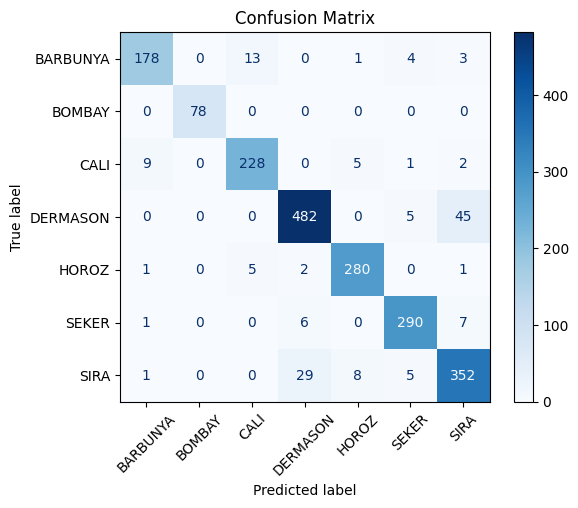

In [70]:
# =========================================
# 18. TEST NO DROPOUT
# =========================================

print("===== NO DROPOUT =====")

evaluate_model(
    model_no_dropout,
    X_test,
    y_test
)

ĐÁNH GIÁ DROPOUT

===== DROPOUT =====

Accuracy: 0.9256

Classification Report:

              precision    recall  f1-score   support

    BARBUNYA       0.94      0.90      0.92       199
      BOMBAY       1.00      1.00      1.00        78
        CALI       0.93      0.93      0.93       245
    DERMASON       0.92      0.92      0.92       532
       HOROZ       0.95      0.97      0.96       289
       SEKER       0.95      0.95      0.95       304
        SIRA       0.87      0.88      0.88       395

    accuracy                           0.93      2042
   macro avg       0.94      0.94      0.94      2042
weighted avg       0.93      0.93      0.93      2042



<Figure size 1000x800 with 0 Axes>

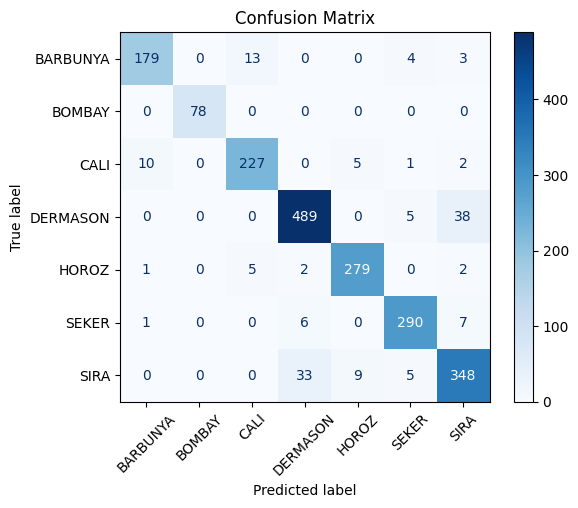

In [71]:
# =========================================
# 19. TEST DROPOUT
# =========================================

print("===== DROPOUT =====")

evaluate_model(
    model_dropout,
    X_test,
    y_test
)

KỊCH BẢN 3: KẾT HỢP DROPOUT VÀ SMOTE

In [72]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim

In [73]:
# =========================================
# 6. CHIA TRAIN / VAL / TEST
# =========================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (9527, 16)
Validation size: (2042, 16)
Test size: (2042, 16)


In [74]:
# =========================================
# 7. ÁP DỤNG SMOTE
# =========================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Class
3    2482
6    1845
5    1419
4    1350
2    1141
0     925
1     365
Name: count, dtype: int64

After SMOTE:
Class
3    2482
4    2482
5    2482
6    2482
0    2482
2    2482
1    2482
Name: count, dtype: int64


In [75]:
# =========================================
# 8. SCALE FEATURES
# =========================================

scaler = StandardScaler()

X_train_smote = scaler.fit_transform(
    X_train_smote
)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [76]:
# =========================================
# 9. CHUYỂN SANG TENSOR
# =========================================

# X
X_train_smote = torch.FloatTensor(
    np.array(X_train_smote)
)

X_val = torch.FloatTensor(
    np.array(X_val)
)

X_test = torch.FloatTensor(
    np.array(X_test)
)

# y
y_train_smote = torch.LongTensor(
    np.array(y_train_smote)
)

y_val = torch.LongTensor(
    np.array(y_val)
)

y_test = torch.LongTensor(
    np.array(y_test)
)

In [77]:
# =========================================
# 10. INPUT SIZE
# =========================================

input_size = X_train_smote.shape[1]

print("Input size:", input_size)

Input size: 16


In [78]:
# =========================================
# 11. MLP DROPOUT MODEL
# =========================================

class MLP_Dropout(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 256),
            nn.ReLU(),
            #nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.ReLU(),
            #nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            #nn.Dropout(0.1),

            nn.Linear(64, 7)
        )

    def forward(self, x):

        return self.network(x)

In [79]:
# =========================================
# 12. TRAIN FUNCTION
# =========================================

def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=300
):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        # =========================
        # TRAIN MODE
        # =========================

        model.train()

        outputs = model(X_train)

        loss = criterion(outputs, y_train)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # =========================
        # TRAIN METRICS
        # =========================

        train_losses.append(loss.item())

        _, predicted = torch.max(outputs, 1)

        train_acc = (
            predicted == y_train
        ).float().mean()

        train_accuracies.append(
            train_acc.item()
        )

        # =========================
        # VALIDATION
        # =========================

        model.eval()

        with torch.no_grad():

            val_outputs = model(X_val)

            val_loss = criterion(
                val_outputs,
                y_val
            )

            val_losses.append(
                val_loss.item()
            )

            _, val_predicted = torch.max(
                val_outputs,
                1
            )

            val_acc = (
                val_predicted == y_val
            ).float().mean()

            val_accuracies.append(
                val_acc.item()
            )

        # =========================
        # PRINT
        # =========================

        if (epoch + 1) % 50 == 0:

            print(
                f"Epoch {epoch+1}/{epochs}"
                f" | Train Loss: {loss.item():.4f}"
                f" | Val Loss: {val_loss.item():.4f}"
                f" | Train Acc: {train_acc.item():.4f}"
                f" | Val Acc: {val_acc.item():.4f}"
            )

    return (
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies
    )

In [80]:
# =========================================
# 13. TRAIN MODEL
# =========================================

model_dropout_smote = MLP_Dropout(input_size)

(
    train_loss,
    val_loss,
    train_acc,
    val_acc

) = train_model(

    model_dropout_smote,

    X_train_smote,
    y_train_smote,

    X_val,
    y_val,

    epochs=300
)

Epoch 50/300 | Train Loss: 0.2681 | Val Loss: 0.3281 | Train Acc: 0.9114 | Val Acc: 0.8893
Epoch 100/300 | Train Loss: 0.1507 | Val Loss: 0.2097 | Train Acc: 0.9456 | Val Acc: 0.9265
Epoch 150/300 | Train Loss: 0.1368 | Val Loss: 0.2028 | Train Acc: 0.9507 | Val Acc: 0.9280
Epoch 200/300 | Train Loss: 0.1301 | Val Loss: 0.2009 | Train Acc: 0.9525 | Val Acc: 0.9280
Epoch 250/300 | Train Loss: 0.1250 | Val Loss: 0.2000 | Train Acc: 0.9543 | Val Acc: 0.9310
Epoch 300/300 | Train Loss: 0.1206 | Val Loss: 0.1999 | Train Acc: 0.9564 | Val Acc: 0.9310


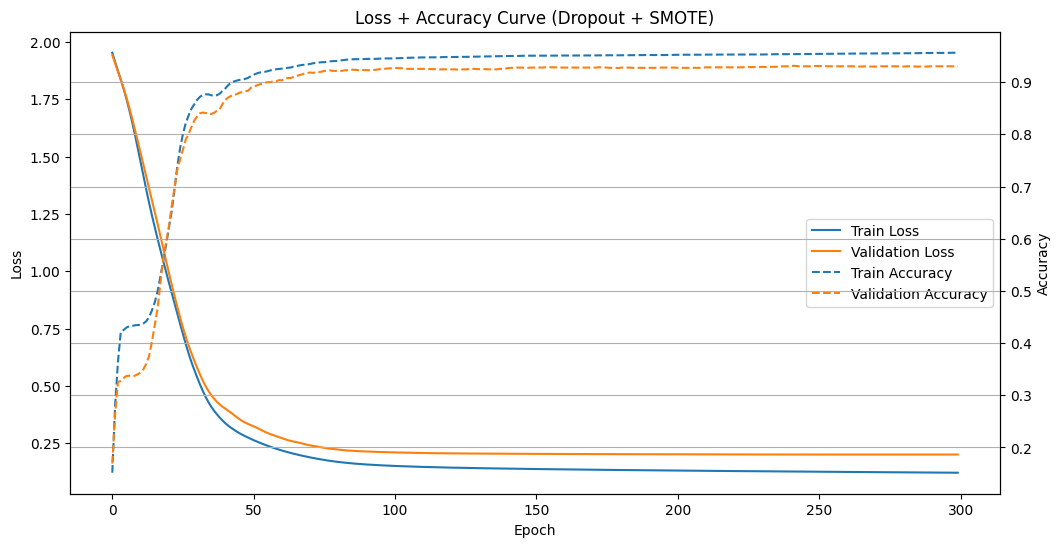

In [81]:
# =========================================
# 14. LOSS + ACCURACY CURVE
# =========================================

fig, ax1 = plt.subplots(figsize=(12,6))

# =========================
# LOSS
# =========================

ax1.plot(
    train_loss,
    label='Train Loss'
)

ax1.plot(
    val_loss,
    label='Validation Loss'
)

ax1.set_xlabel('Epoch')

ax1.set_ylabel('Loss')

# =========================
# ACCURACY
# =========================

ax2 = ax1.twinx()

ax2.plot(
    train_acc,
    label='Train Accuracy',
    linestyle='--'
)

ax2.plot(
    val_acc,
    label='Validation Accuracy',
    linestyle='--'
)

ax2.set_ylabel('Accuracy')

# =========================
# TITLE
# =========================

plt.title(
    "Loss + Accuracy Curve (Dropout + SMOTE)"
)

# =========================
# LEGEND
# =========================

lines_1, labels_1 = ax1.get_legend_handles_labels()

lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='center right'
)

plt.grid(True)

plt.show()

In [82]:
# =========================================
# 15. EVALUATE MODEL
# =========================================

def evaluate_model(
    model,
    X_test,
    y_test
):

    # =========================
    # INFERENCE MODE
    # =========================

    model.eval()

    with torch.no_grad():

        outputs = model(X_test)

        _, predictions = torch.max(
            outputs,
            1
        )

    predictions = predictions.numpy()

    y_true = y_test.numpy()

    # =========================
    # ACCURACY
    # =========================

    accuracy = accuracy_score(
        y_true,
        predictions
    )

    print(f"\nAccuracy: {accuracy:.4f}")

    # =========================
    # CLASSIFICATION REPORT
    # =========================

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_true,
            predictions,
            target_names=encoder.classes_
        )
    )

    # =========================
    # CONFUSION MATRIX
    # =========================

    cm = confusion_matrix(
        y_true,
        predictions
    )

    plt.figure(figsize=(10,8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=encoder.classes_
    )

    disp.plot(
        cmap="Blues",
        values_format='d'
    )

    plt.title(
        "Confusion Matrix (Dropout + SMOTE)"
    )

    plt.xticks(rotation=45)

    plt.show()


Accuracy: 0.9202

Classification Report:

              precision    recall  f1-score   support

    BARBUNYA       0.94      0.90      0.92       199
      BOMBAY       1.00      1.00      1.00        78
        CALI       0.93      0.93      0.93       245
    DERMASON       0.95      0.88      0.91       532
       HOROZ       0.94      0.97      0.95       289
       SEKER       0.94      0.96      0.95       304
        SIRA       0.83      0.91      0.87       395

    accuracy                           0.92      2042
   macro avg       0.93      0.93      0.93      2042
weighted avg       0.92      0.92      0.92      2042



<Figure size 1000x800 with 0 Axes>

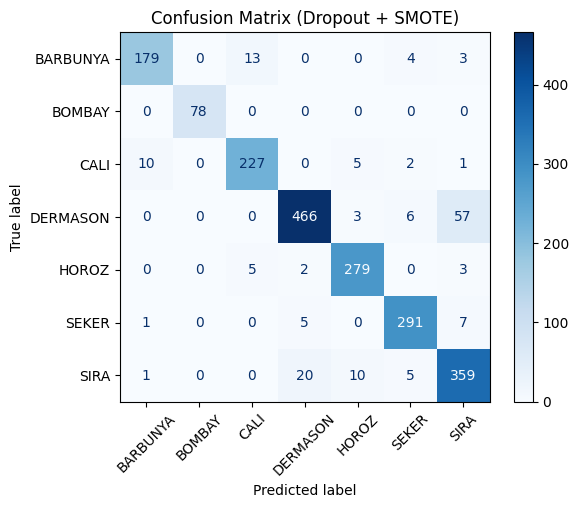

In [83]:
# =========================================
# 16. TEST MODEL
# =========================================

evaluate_model(
    model_dropout_smote,
    X_test,
    y_test
)